# Build a SeisSol dynamic-rupture deck, from raw data

You bring **raw data and a mesh**. This notebook builds every gridded input, uses those
freshly built files to work out the physical parameters, and writes a folder you can run.

It is deliberately thin: all the logic lives in `deckbuild/`, so each section is a
PARAMETERS cell followed by `build` / `verify` / `plot`. Edit the parameters, Run All.

**Order is not cosmetic.** The stress closure needs `Sv(z)` from the material and the
friction zoning needs the thermal field, so **material runs first**. Running them out of
order is the likeliest way to pair a new velocity model with a stale stress field.

### How to trace anything in this notebook

Every code cell opens with a `══ STEP ══` header listing the functions it calls and the
file each one lives in, so you can go from a printed number to the code that produced it
without searching.

| you want | look at |
|:--|:--|
| what a stage does and its gates | `deckbuild/<stage>.py` — `material`, `stress`, `friction`, `mesh`, `deck` |
| the descriptor schema and validation | `deckbuild/config.py` |
| the fault frame, snapping, tractions | `deckbuild/geometry.py` |
| the NetCDF layout SeisSol reads | `deckbuild/asagi.py` |
| raw slices → a uniform grid | `deckbuild/rawslices.py` |
| the mesh↔deck compatibility check | `deckbuild/stage_f.py` |
| what a gate name means | the `GateReport` line prints the gate id; grep it in `deckbuild/` |
| the module map and conventions | `CODEBASE_GUIDE.md` |
| meshing | `MESHING.md`, then `skills/code-mesh-build-improve/SKILL.md` |
| why the design is shaped this way | `docs/PLAN_integrated_workflow_notebook_2026-08-01.md` |

In Jupyter you can also jump straight to a source file:

```python
from deckbuild.material import MaterialStage
MaterialStage.build??          # shows the source and its path
```

Every gate id (`M1`, `V2`, `G4`, `F0`, `A`–`G`, `P1`–`P8`) is a literal string in the
module that raises it, so `grep -rn '"P5"' deckbuild/` takes you to the check itself.

## [0] Setup and project

In [1]:
# ══ STEP 0 · locate the workflow, load the descriptor ═══════════════════════════
#   init()          deckbuild/bootstrap.py  find the folder, put it on sys.path, RELOAD
#                                           every deckbuild.* module, ensure outputs/
#   Project.load()  deckbuild/config.py     parse + STRICTLY validate the descriptor.
#                                           data_dir= re-points every `path:` in it.
#   cfg.summary()   deckbuild/config.py
# ---- PARAMETERS ----------------------------------------------------------------
PROJECT       = "demo_planar"    # a descriptor stem under projects/
RAW_DATA_DIR  = None             # where YOUR raw data lives.  None -> data/<PROJECT>/
                                 # e.g. "/data/my_fault/raw_exports"
REQUIRE_FILES = True             # False skips existence checks, never schema checks
# ----------------------------------------------------------------------------------
from pathlib import Path
from deckbuild.bootstrap import init
from deckbuild.config import Project

B = init(project=PROJECT, require_files=False)          # locate + path + reload
if RAW_DATA_DIR is None:
    cfg = Project.load(B.root / "projects" / f"{PROJECT}.yaml",
                       require_files=REQUIRE_FILES)
else:
    # Point the descriptor at YOUR data.  Every `path:` in the descriptor is resolved
    # against this directory, so the same descriptor works wherever the data sits.
    cfg = Project.load(B.root / "projects" / f"{PROJECT}.yaml",
                       require_files=REQUIRE_FILES, data_dir=Path(RAW_DATA_DIR))
print(cfg.summary())

deckbuild bootstrap  (reloaded 13 module(s))
project      : demo_planar
descriptor   : /Users/chunhuizhao/projects/integrated_workflow/projects/demo_planar.yaml
crs          : EPSG:32610
strike       : az 0.0 deg from (500000.0, 4000000.0)
default mesh : planar  (of ['planar'])
gate bands   : ['demo bend']
raw sources  : orientation=constant velocity=layered_1d thermal=depth_profile
data dir     : /Users/chunhuizhao/projects/integrated_workflow/data/demo_planar
outputs      : /Users/chunhuizhao/projects/integrated_workflow/outputs
  ! require_files=False -- input existence was NOT checked
project      : demo_planar
descriptor   : /Users/chunhuizhao/projects/integrated_workflow/projects/demo_planar.yaml
crs          : EPSG:32610
strike       : az 0.0 deg from (500000.0, 4000000.0)
default mesh : planar  (of ['planar'])
gate bands   : ['demo bend']
raw sources  : orientation=constant velocity=layered_1d thermal=depth_profile
data dir     : /Users/chunhuizhao/projects/integrated_workflow/

In [2]:
# ══ STEP 0b · inventory the raw inputs ═════════════════════════════════════════
#   cfg.raw.{orientation,velocity,thermal}  deckbuild/config.py -> RawSources/SourceSpec
#   cfg.resolve_path()                      deckbuild/config.py -> descriptor-relative
#   cfg.mesh()                              deckbuild/config.py -> the default MeshSpec
# Reads nothing; just shows what the next steps will consume.
# What raw data did we actually find?
from pathlib import Path
for label, spec in (("orientation", cfg.raw.orientation), ("velocity", cfg.raw.velocity),
                    ("thermal", cfg.raw.thermal)):
    if spec is None:
        print(f"  {label:12} (none)"); continue
    n = ""
    if spec.path:
        hits = sorted(Path(cfg.data_dir).glob(spec.path)) if any(c in spec.path for c in "*?[") \
               else ([Path(cfg.resolve_path(spec.path))] if Path(cfg.resolve_path(spec.path)).exists() else [])
        n = f"  ({len(hits)} file(s))"
    print(f"  {label:12} kind={spec.kind:14}{n}")
print(f"  {'mesh':12} {cfg.resolve_path(cfg.mesh().path)}")

  orientation  kind=constant      
  velocity     kind=layered_1d    
  thermal      kind=depth_profile 
  mesh         /Users/chunhuizhao/projects/integrated_workflow/data/demo_planar/demo_planar.puml.h5


## [1] What we are building

```
RAW (you provide)        BUILT HERE                     CONSUMED BY
-----------------        ----------                     -----------
velocity model       ->  material nc               ->   deck; Vs gate; L_b
                          +-> plasticity nc        ->   deck (if plasticity on)
                          +-> Sv(z) profile        ->   STRESS closure
                          +-> Qp/Qs relation       ->   deck yaml (if Q on)
temperature / depth  ->  thermal nc or profile     ->   FRICTION zoning
stress orientation   ->  SHmax(x,y), R(x,y)        ->   STRESS orientation
fault mesh           ->  .puml.h5 + gates          ->   deck; all projections
                                  |
                                  v
              STRESS nc, FRICTION nc, rs_muw LuaMap
                                  |
                                  v
              PARAMETER DETERMINATION (reads the BAKED ncs, on the real mesh)
                                  |
                                  v
              DECK FOLDER (ncs + yamls + par + receivers + mesh)
```

Parameter determination happens **after** baking, never before: every read-out samples the
written NetCDF at the real fault facets, so what you tune against is what SeisSol reads.

In [3]:
# ══ STEP 1 · declare the output layout BEFORE writing anything ═════════════════
# One declared home per artifact -- see the filename contract in README.md and
# DeckStage.resolve_paths (deckbuild/deck.py), which implements it.
#   RUN_TAG keeps two parameter sets from overwriting each other.
# Where EVERYTHING will land -- printed before anything is written.
RUN_TAG = "k1.7_case1_fz500"
OUT  = B.root / "outputs" / cfg.name / RUN_TAG
DECK = B.root / "decks" / f"{cfg.name}_{RUN_TAG}_nb"   # _nb: the notebook owns this deck;
                                                     # run_workflow.py writes _cli.
for sub in ("material", "stress", "friction"):
    (OUT / sub).mkdir(parents=True, exist_ok=True)
print(f"artifacts -> {OUT}\ndeck      -> {DECK}")

artifacts -> /Users/chunhuizhao/projects/integrated_workflow/outputs/demo_planar/k1.7_case1_fz500
deck      -> /Users/chunhuizhao/projects/integrated_workflow/decks/demo_planar_k1.7_case1_fz500_nb


## [2] Mesh — **ingest**, convert, gate

This notebook does **not** build a mesh. To build or improve one, open
`skills/code-mesh-build-improve/SKILL.md` with Claude; `MESHING.md` is the one-page map.
Here we ingest the mesh the descriptor points at, gate it (A–G), and snap the hypocentre
onto it.

In [4]:
# ══ STEP 2 · INGEST the mesh (this notebook never BUILDS one) ══════════════════
#   MeshStage.build()   deckbuild/mesh.py   register an existing .puml.h5, or convert a
#                                           .msh via msh_to_puml() in the same file
#   To BUILD or IMPROVE a mesh: skills/code-mesh-build-improve/SKILL.md + MESHING.md
# ---- PARAMETERS ----------------------------------------------------------------
HYPOCENTER      = None    # None -> take it from the descriptor; or dict(lon=, lat=, depth_m=)
HYPO_SNAP_TOL_M = None    # None -> the descriptor's value
# ----------------------------------------------------------------------------------
from deckbuild.mesh import MeshStage
mesh_art = MeshStage().build(cfg, OUT)
print(f"ingested {mesh_art.path}")

ingested /Users/chunhuizhao/projects/integrated_workflow/data/demo_planar/demo_planar.puml.h5


In [5]:
# ══ STEP 2b · snap the hypocentre onto the real fault ══════════════════════════
#   load_fault()       deckbuild/geometry.py  BC-3 facets -> centroids, normals, the
#                                             Tandem (strike, dip) basis
#   snap_hypocenter()  deckbuild/geometry.py  nearest facet CENTROID; HARD-fails past
#                                             snap_tol_m; warns if the snap crosses a
#                                             named gate band
#   Hypocenter         deckbuild/config.py    lon/lat/depth OR projected x/y/z
import dataclasses
from deckbuild.config import Hypocenter
from deckbuild.geometry import load_fault, snap_hypocenter

fault = load_fault(cfg.mesh(), cfg.data_dir, strike=cfg.strike)
hypo  = cfg.hypocenter() if HYPOCENTER is None else Hypocenter(**HYPOCENTER)
if HYPO_SNAP_TOL_M is not None:
    hypo = dataclasses.replace(hypo, snap_tol_m=HYPO_SNAP_TOL_M)
snap = snap_hypocenter(hypo, fault, cfg.strike, cfg.crs, gate_bands=cfg.gate_bands)
snap.report.print()

=== hypocentre snap (demo 8 km hypocentre) ===
[PASS] H1: requested (500000.0, 4005000.0, -8000.0) -> facet 111 at (500000.0, 4004166.7, -8333.3); moved 897.6 m (tol 2000 m); s = 4.17 km, depth = 8333.3 m
PASS: 1/1 hard, 0 warn, 0 skipped


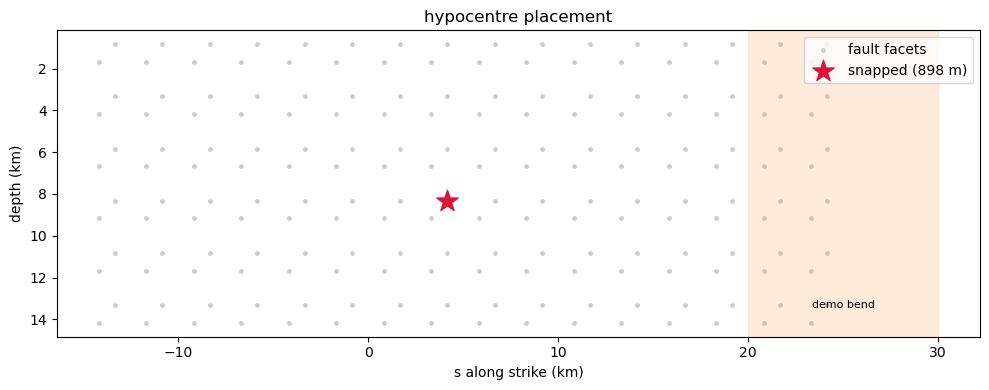

In [6]:
# ══ STEP 2c · look at where it landed ══════════════════════════════════════════
#   fault.s_km()     deckbuild/geometry.py  along-strike distance via strike_s_km()
#   fault.depth_m    deckbuild/geometry.py  positive-down depth of each facet centroid
# No rule can tell a correct snap from one onto the WRONG STRAND -- hence the plot.
# Plot requested vs snapped ON the fault.  No rule can tell a correct snap from one onto
# the WRONG STRAND -- that is why this plot exists.
import matplotlib.pyplot as plt, numpy as np
s = fault.s_km(cfg.strike); d = fault.depth_m / 1000.0
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(s, d, s=6, c="0.8", label="fault facets")
ax.scatter([snap.s_km], [snap.depth_m / 1000.0], marker="*", s=260,
           c="crimson", zorder=5, label=f"snapped ({snap.distance_m:.0f} m)")
for b in cfg.gate_bands:
    ax.axvspan(b.s_start_km, b.s_end_km, alpha=.15, color="tab:orange")
    ax.text(0.5*(b.s_start_km+b.s_end_km), d.max()*0.95, b.name, ha="center", fontsize=8)
ax.invert_yaxis(); ax.set_xlabel("s along strike (km)"); ax.set_ylabel("depth (km)")
ax.legend(); ax.set_title("hypocentre placement"); plt.tight_layout(); plt.show()

## [3] Material — raw velocity → nc, plasticity, Sv(z)

**Runs first**, because stress needs its `Sv(z)` and friction may need its thermal field.

`plastCo = 1e-4 mu` is LINEAR in mu, so ASAGI's interpolation of the cohesion stays exactly
consistent with the shear modulus each element sees. `bulkFriction` is `tan(phi)` — the
COEFFICIENT, not degrees; SeisSol computes `atan()` of it.

In [7]:
# ══ STEP 3 · MATERIAL, and the two opt-in physics ══════════════════════════════
# Runs FIRST: stress needs its Sv(z) and friction may need its thermal field.
#   MaterialStage.build()   deckbuild/material.py  velocity -> {rho, mu, lambda};
#                             + plasticity nc; + the Sv(z) profile; + thermal (ctm)
#     reader dispatch        deckbuild/material.py  VELOCITY_READERS[kind]
#       layered_1d           deckbuild/material.py  _layered_1d()
#       cvm_slices           deckbuild/material.py  _cvm_slices() -> rawslices.py
#     slice pipeline         deckbuild/rawslices.py interp_slices()
#     Sv(z)                  deckbuild/material.py  sv_profile_from_material()
#     plasticity             deckbuild/material.py  derive_plasticity() (Roten 2014)
#   MaterialStage.verify()  deckbuild/material.py  gates M1-M7
#   write_asagi()           deckbuild/asagi.py     the NetCDF layout SeisSol reads
# ---- PARAMETERS ----------------------------------------------------------------
# The material itself ({rho, mu, lambda}) is ALWAYS built -- SeisSol cannot run without
# it.  The next two are ADVANCED, OPT-IN physics: both default OFF, and turning either on
# changes what SeisSol computes and what binary you need.
WITH_PLASTICITY  = False   # off-fault Drucker-Prager yielding (Roten et al. 2014).
                           #   ON  -> writes a plasticity nc; sets Plasticity = 1.
                           #   Costs run time and DISSIPATES energy: on SAFS it lowered
                           #   Mw and, alone, blocked the San Gorgonio gate.
WITH_ATTENUATION = False   # intrinsic (anelastic) Q, from the CVM's own Vs.
                           #   ON  -> writes Qp/Qs settings into the deck.
                           #   *** REQUIRES a VISCOELASTIC SeisSol build.  EQUATIONS=
                           #   viscoelastic2 is a BUILD-time choice, not a runtime flag;
                           #   an elastic binary CANNOT read the resulting deck. ***

# --- only read when WITH_PLASTICITY is True ---
PHI_SOFT, PHI_HARD = 35.0, 45.0   # friction angle, deg: soft rock / hard rock.
                                  # 35/45 is Roten et al. (2014).  The SAFS production
                                  # decks use 30/40 -- neither is a silent default.
VS_THRESHOLD       = 2500.0       # m/s: the Vs that splits soft from hard
COHESION_FACTOR    = 1.0e-4       # c = factor * mu   (Roten cohesion model 3)

# --- only read when WITH_ATTENUATION is True ---
Q_FREQ_CENTRAL     = 0.5          # Hz: Q is held ~constant over a band centred here.
Q_FREQ_RATIO       = 100.0        # the band is FreqCentral * sqrt(ratio) either side;
                                  # OUTSIDE it Q -> infinity, i.e. the medium goes elastic.
# ----------------------------------------------------------------------------------
from deckbuild.material import AttenuationSpec, MaterialStage, PlasticitySpec
mstage = MaterialStage()
mat = mstage.build(
    cfg, OUT / "material",
    plasticity=PlasticitySpec(PHI_SOFT, PHI_HARD, VS_THRESHOLD, COHESION_FACTOR)
              if WITH_PLASTICITY else None,
    attenuation=AttenuationSpec(freq_central=Q_FREQ_CENTRAL, freq_ratio=Q_FREQ_RATIO)
              if WITH_ATTENUATION else None)
print(f"plasticity : {'ON  -> ' + Path(mat.plasticity.path).name if mat.plasticity else 'off'}")
print(f"attenuation: {'ON  (needs a viscoelastic build!)' if mat.attenuation else 'off'}")
mstage.verify(cfg, mat, plasticity_artifact=mat.plasticity).print()

plasticity : off
attenuation: off
=== material M1-M5 (material.nc) ===
[PASS] M1: lambda > 0 everywhere: min = 7.084e+09 Pa
[PASS] M2: no NaN/Inf after interpolation: 0 bad node(s)
[PASS] M3: fault bbox: 192 point(s) vs grid hull; per-axis margin (low, high) x: [+30000.0, +30000.0] m; y: [+15833.3, +15833.3] m; z: [+5833.3, +833.3] m
[PASS] M4: mu: median |nc - direct| = 4.787e+04 (tol 2e+08) over 400 seed-12345 points
[PASS] M4max: mu: max |nc - direct| = 2.190e+07 (tol 2e+09)
[PASS] M5: Vs in a plausible range: [1700.0, 3900.0] m/s
PASS: 5/5 hard, 0 warn, 0 skipped


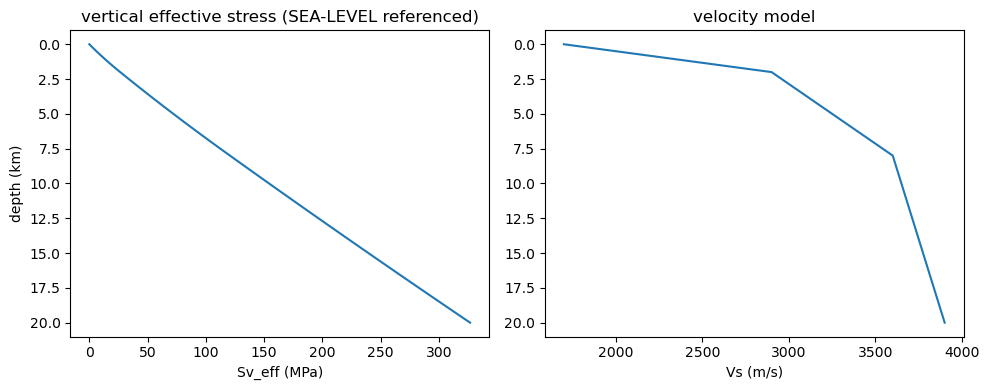

In [8]:
# ══ STEP 3b · LOOK at the material: slices, a fault-following section, Sv ══════
#   plot_material_slices()   deckbuild/plots.py
#     vs_from_material()     deckbuild/plots.py     Vs = sqrt(mu/rho) from the nc
#     fault_trace()          deckbuild/geometry.py  the fault's map trace AT a depth --
#                                                   a 3-D surface moves with depth, so
#                                                   the z=0 trace is WRONG on a 10 km cut
#     _section_along_fault() deckbuild/plots.py     samples the nc down the fault's own
#                                                   CURVED trace; its x-axis is the same
#                                                   along-strike s the on-fault figures
#                                                   use, so the two read together
# What to look for: the fault curve must stay inside the coloured region on every slice
# (that is gate M3/V4hull, by eye), and the near-surface low-Vs basins should sit where
# you expect them -- they are what will amplify ground motion.
#
# The Sv_eff panel is SEA-LEVEL referenced: depth 0 means z = 0, NOT the top of the grid.
# Referencing it to the grid top instead offsets every stress field by z_max -- +3250 m
# on the SAFS CVM -- and gate V2 cannot catch it, because V2 checks an eigenvalue RATIO.
# See sv_profile_from_material() in deckbuild/material.py.
# ---- PARAMETERS ----------------------------------------------------------------
SLICE_DEPTHS_KM = (0.0, 5.0, 10.0)   # horizontal cuts, positive-down
# ----------------------------------------------------------------------------------
from deckbuild.plots import plot_material_slices
plot_material_slices(mat.material.path, fault, depths_km=SLICE_DEPTHS_KM, cfg=cfg,
                     sv_profile=mat.sv_profile.path)
plt.show()

## [4] Stress — orientation × Sv × closure k

Andersonian C1: `sig2 = Sv_eff` (**vertical** — a strike-slip assumption),
`sig3 = Sv_eff/((1-R)k + R)`, `sig1 = k sig3`. Compression-**negative** Pa in the nc.

`k` is a column property, so a graded design is the same code path as a scalar. The
shallow freeze makes every node above its depth carry its own column's stress evaluated
*at* that depth — without it the trace band sits under 1 MPa and slides all run.

In [9]:
# ══ STEP 4 · STRESS ════════════════════════════════════════════════════════════
#   KDesign             deckbuild/stress.py  the N-region closure-ratio design
#   StressStage.build() deckbuild/stress.py  orientation x Sv x k -> {s_xx..s_xz}
#     closure           deckbuild/stress.py  magnitudes_C1()   (sigma2 VERTICAL)
#     tensor            deckbuild/stress.py  build_tensor_andersonian()
#     k(s)              deckbuild/stress.py  k_profile_1d()    (smoothstep windows)
#     orientation       deckbuild/orientation.py  read_orientation() -> csm_csv |
#                                                 constant | callable
#   StressStage.verify() deckbuild/stress.py gates V1-V4
# ---- PARAMETERS ----------------------------------------------------------------
K_VALUES        = [1.7]     # one k per along-strike region
K_BOUNDARIES    = []        # exactly len(K_VALUES)-1 smoothstep windows, e.g. [(150,160)]
FREEZE_ABOVE_M  = 500.0     # 0 disables the shallow freeze
# ----------------------------------------------------------------------------------
from deckbuild.stress import KDesign, StressStage
sstage = StressStage()
kdes = KDesign(k_values=tuple(K_VALUES),
               boundaries_s_km=tuple(tuple(b) for b in K_BOUNDARIES))
stress = sstage.build(cfg, OUT / "stress", sv_profile=mat.sv_profile, design=kdes,
                      freeze_above_depth_m=FREEZE_ABOVE_M)
sstage.verify(cfg, stress, design=kdes).print()

=== stress V1-V4 (stress_andersonian_k1.7_freeze500m.nc) ===
[ -- ] V1: not run HERE: regional bit-identity needs the Sv profile and a scratch dir.  Call StressStage.verify_regions(...) and merge its report with rep.extend() for the complete V1-V4 battery.
[PASS] V2: eig sigma1/sigma3 vs k(s) at z = -20000 m: max |d| = 2.31e-08 over 4331 columns (k range 1.700-1.700)
[PASS] V3: freeze: 2 level(s) above -500 m all equal the z = -500 m slice
[PASS] V4hull: fault facets: 192 point(s) vs grid hull; per-axis margin (low, high) x: [+30000.0, +30000.0] m; y: [+15833.3, +15833.3] m; z: [+5833.3, +833.3] m
[PASS] V4a: sigma_n > 0 on every facet: min = 10.331 MPa (tau_0 min = 2.6784 MPa)
[PASS] V4b: mu_app finite on 192/192 facets; max mu_app = 0.2593
PASS: 4/4 hard, 0 warn, 1 skipped


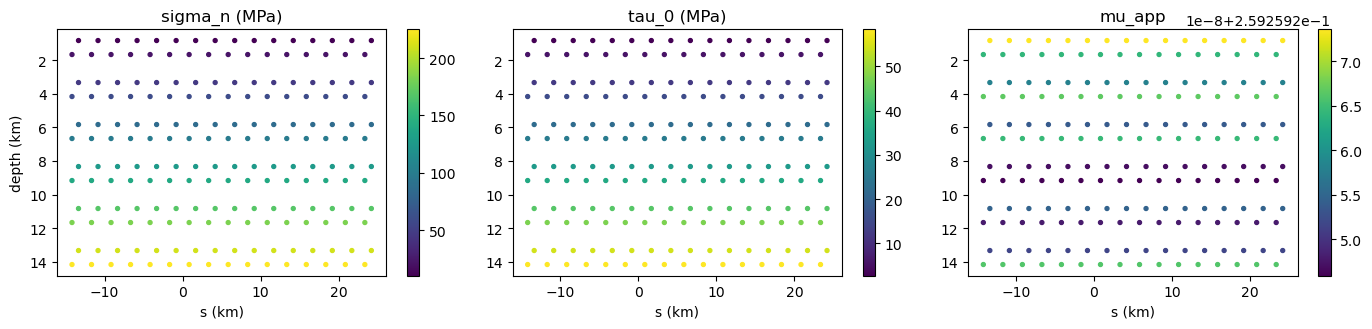

min sigma_n 10.33 MPa | min tau_0 2.678 MPa | max mu_app 0.259


In [10]:
# ══ STEP 4b · project the stress ONTO the fault and LOOK at it ═════════════════
#   project_stress_onto_fault()  deckbuild/stage_f.py  samples the WRITTEN nc at the real
#     facet centroids, then resolves tractions -- so what you see is what SeisSol reads.
#       trilinear_sample()   deckbuild/asagi.py
#       resolve_tractions()  deckbuild/geometry.py   (compression-POSITIVE MPa)
#   plot_onfault()               deckbuild/plots.py  one full-width (s, depth) panel per
#     field + a map view.  Two panels are DERIVED, and they are the ones a design turns on:
#       dtau_dyn = (mu_app - f_w) * sigma_n     what each patch can actually pay out
#       S = (f0*sigma_n - tau)/(tau - f_w*sigma_n)   higher = harder to break
#     Colour limits are PERCENTILES: one bad facet at a corner would otherwise flatten
#     the whole field to a single colour and hide everything.
from deckbuild.stage_f import project_stress_onto_fault
from deckbuild.friction import FwDesign
from deckbuild.plots import plot_onfault
sn, tau, mu = project_stress_onto_fault(stress.path, fault)
# FwDesign.f0 is the dataclass default (0.6); the friction step below lets you override
# it via F0.  Reading it here keeps the two from drifting apart silently.
plot_onfault(fault, cfg, {"sigma_n (MPa)": sn, "tau_0 (MPa)": tau, "mu_app": mu},
             snap=snap, f0=FwDesign.f0)
plt.show()
print(f"min sigma_n {np.nanmin(sn):.2f} MPa | min tau_0 {np.nanmin(tau):.3f} MPa | "
      f"max mu_app {np.nanmax(mu):.3f}")

## [5] Friction — a(T), V_w(T), and the graded `f_w` LuaMap

`rs_b` is a **scalar**: SeisSol v1.1.3 FL=103 never reads it spatially.

Spatial `rs_muw` needs SeisSol **newer than v1.3.2** — v1.1.3 accepts the YAML and
*silently ignores it*, so the run completes and is wrong. Check before you build.

### CASE 1 vs CASE 2 — what actually differs

Both map temperature to `a - b` (the rate-and-state stability parameter) and to `V_w` (the
strong-rate-weakening slip rate). They differ **only in the shallow zone**, and that one
difference changes the whole design.

| | CASE 1 — three zones | CASE 2 — two zones |
|:--|:--|:--|
| `T <= 50 °C` (shallow) | `a-b = +0.004` → velocity **STRENGTHENING** | `a-b = -0.004` → velocity **WEAKENING** |
| `50 – 150 °C` | ramps through 0 at 100 °C | still weakening |
| `150 – 300 °C` (seismogenic) | `a-b = -0.004` → weakening | `a-b = -0.004` → weakening |
| `T >= 300 °C` (deep) | ramps back up, 0 at 350 °C → strengthening | identical |
| the trace | **stable**: a shallow VS lid resists slip | **unstable**: VW all the way to the surface |

`a - b < 0` is velocity-weakening — slip can accelerate, so rupture nucleates and
propagates. `a - b > 0` is velocity-strengthening — the fault resists, so it acts as a
barrier.

**Why it matters for you:** CASE 2 has no shallow lid, so ruptures reach the free surface
and produce far more slip at the trace. A `k` or `f_w` calibration made on CASE 1 does
**not** transfer to CASE 2 — the SAFS work found this the hard way. `V_w` is the same in
both: 0.05 m/s up to 350 °C, ramping to 1000 m/s by 400 °C (which switches strong
weakening off in the deep VS zone).

In [11]:
# ══ STEP 5 · FRICTION ══════════════════════════════════════════════════════════
#   check_seissol_supports_spatial_muw()  deckbuild/friction.py
#     v1.1.3 accepts a spatial rs_muw and SILENTLY IGNORES it -- check BEFORE building.
#   The a-b(T) and V_w(T) profiles are a_minus_b()/a_of_T()/vw_of_T() in
#   deckbuild/friction.py; unit_self_test() there checks them before any baking.
# ---- PARAMETERS ----------------------------------------------------------------
CASE          = 1     # which thermal zoning to use -- see the table above.
                      #   1 = three zones: VS shallow / VW seismogenic / VS deep
                      #   2 = two zones:   VW from the SURFACE down to the deep VS
FW_VALUES     = [0.0, 0.05]     # the strong-rate-weakening FLOOR f_w, one per region,
                                # ordered along increasing s.  Lower f_w = weaker at high
                                # slip rate = LARGER dynamic stress drop.
FW_BOUNDARIES = [(10.0, 20.0)]  # exactly len(FW_VALUES)-1 smoothstep windows, in s (km)
F0            = 0.6   # the REFERENCE friction coefficient of the rate-and-state law:
                      # the steady-state friction at the reference slip rate RS_sr0.
                      # It is the ceiling f_w is measured against -- gate F0 requires
                      # 0 <= f_w < f0 in every region, because f_w is the value friction
                      # DECAYS TO at high slip rate, and decaying UP to or past the
                      # reference would mean the fault strengthens when it slips fast.
                      # 0.6 is the Byerlee-like value used throughout the SAFS decks.
SEISSOL_SRC   = None  # path to your SeisSol tree, to check spatial rs_muw support
# ----------------------------------------------------------------------------------
from deckbuild.friction import (FrictionStage, FwDesign,
                                check_seissol_supports_spatial_muw, nucleation_lua)
check_seissol_supports_spatial_muw(SEISSOL_SRC).print()

=== SeisSol spatial rs_muw support ===
[ -- ] F-VER: no SeisSol source tree given; spatial rs_muw support UNKNOWN
PASS: 0/0 hard, 0 warn, 1 skipped


In [12]:
# ══ STEP 5b · build the friction nc and the graded f_w map ═════════════════════
#   FrictionStage.build()        deckbuild/friction.py -> {rs_a, rs_srW}
#     thermal source dispatch    ctm_slices (a thermal nc) | depth_profile
#     depth_profile_fields()     deckbuild/friction.py
#   FrictionStage.verify()       deckbuild/friction.py  gates G1-G4
#   FwDesign                     deckbuild/friction.py  N-region f_w, validates gate F0
#   build_fw_map()               deckbuild/friction.py -> write_lua_map(), the shippable
#                                                          !LuaMap
#   verify_fw_map()              deckbuild/friction.py  gates F0, F1, FL, FLframe
fstage = FrictionStage()
friction = fstage.build(cfg, OUT / "friction", case=CASE)
fstage.verify(cfg, friction).print()

fwdes = FwDesign(fw_values=tuple(FW_VALUES),
                 boundaries_s_km=tuple(tuple(b) for b in FW_BOUNDARIES), f0=F0)
fw = fstage.build_fw_map(cfg, OUT / "friction", fwdes)
fstage.verify_fw_map(cfg, fw, fwdes).print()

=== friction G1-G4 (friction_depth_profile.nc) ===
[PASS] G1: fault centroids: 192 point(s) vs grid hull; per-axis margin (low, high) x: [+30000.0, +30000.0] m; y: [+15833.3, +15833.3] m; z: [+5833.3, +833.3] m
[PASS] G2a: rs_a > 0 everywhere: min = 0.015
[PASS] G2b: rs_srW in [0.05, 1000.0]: [0.05, 1000]
[ -- ] G3: depth-profile source: the field IS the profile, so the round-trip check is vacuous
[PASS] G4: a == b + -0.004 = 0.015 on 160247 node(s) (the velocity-weakening plateau); a range [0.015, 0.023]
PASS: 4/4 hard, 0 warn, 1 skipped
=== graded f_w (fault_rs_muw_0-0.05.yaml) ===
[PASS] F0: admissible: 2 region(s), all 0 <= f_w < f0 = 0.6, windows ordered and disjoint
[PASS] FL: the emitted Lua reproduces the design over s in [-50, 500] km: max |d| = 0.000e+00
[PASS] F1: gate plateau (s <= 10 km) holds f_w = 0 exactly on 121 probe point(s)
[PASS] FLframe: the emitted Lua uses the descriptor's strike origin (500000.0)
PASS: 4/4 hard, 0 warn, 0 skipped


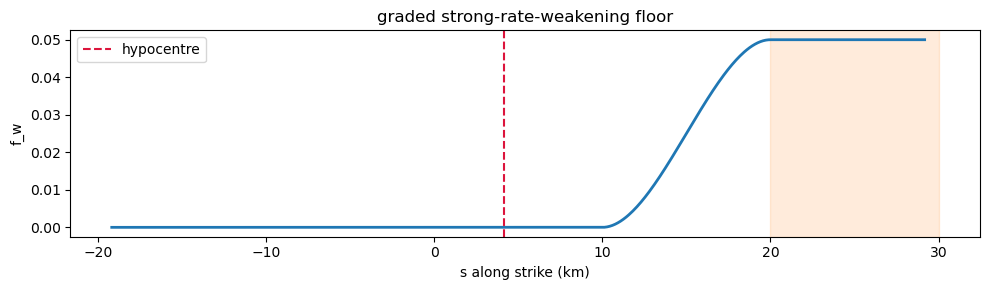

In [13]:
# ══ STEP 5c · look at the f_w design ═══════════════════════════════════════════
#   fw_profile_1d()  deckbuild/friction.py  the same function the emitted Lua computes
#                                           (gate FL asserts they agree)
from deckbuild.friction import fw_profile_1d
ss = np.linspace(float(s.min()) - 5, float(s.max()) + 5, 600)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ss, fw_profile_1d(ss, fwdes), lw=2)
ax.axvline(snap.s_km, color="crimson", ls="--", label="hypocentre")
for b in cfg.gate_bands:
    ax.axvspan(b.s_start_km, b.s_end_km, alpha=.15, color="tab:orange")
ax.set_xlabel("s along strike (km)"); ax.set_ylabel("f_w"); ax.legend()
ax.set_title("graded strong-rate-weakening floor"); plt.tight_layout(); plt.show()

## [6] Assemble the deck + pre-flight P1–P8

The pre-flight reads the assembled deck's live `file:` targets — it tests what SeisSol
will actually read, not what is in memory.

`P6` is a **warning by design**: kappa is necessary, not sufficient. A design passed this
screen and still arrested at s ≈ 60 km on the cluster.

In [14]:
# ══ STEP 6 · ASSEMBLE the deck ═════════════════════════════════════════════════
#   nucleation_lua()  deckbuild/friction.py  the SCEC compact bell, centred on the
#                                            SNAPPED hypocentre (never the requested one)
#   DeckSpec          deckbuild/deck.py      what goes in beyond the artifacts
#   resolve_paths()   deckbuild/deck.py      the path map WITHOUT writing -- the filename
#                                            contract, also in README.md
# ---- PARAMETERS ----------------------------------------------------------------
MU_S          = 0.6        # static strength, for the t=0 pre-slip check
END_TIME_S    = 20.0
NUC_RADIUS_M  = 2000.0
NUC_AMP_MPA   = 75.0
DECK_NOTES    = ""         # preserved verbatim across regeneration
# ----------------------------------------------------------------------------------
from deckbuild.deck import DeckSpec, DeckStage, resolve_paths
# z = -1 m, NEVER 0: SeisSol v1.1.3 silently DROPS a receiver at the free surface.
receivers = np.array([[cfg.stress_box.xmin + 5000.0 * i,
                       cfg.stress_box.ymin + 5000.0 * i, -1.0] for i in range(1, 6)])
arts = {"material": mat.material, "stress": stress,
        "friction": friction, "mesh": mesh_art}
if mat.plasticity is not None:            # only when WITH_PLASTICITY
    arts["plasticity"] = mat.plasticity
spec = DeckSpec(prefix=f"{cfg.name}_",
                plasticity=mat.plasticity is not None,
                attenuation=mat.attenuation,
                receivers=receivers, mu_s=MU_S, end_time_s=END_TIME_S,
                rs_muw_lua=Path(fw.path).read_text(),
                nucleation_lua=nucleation_lua(snap, NUC_RADIUS_M, NUC_AMP_MPA),
                notes=DECK_NOTES)
for k, e in resolve_paths(DECK, arts, spec).items():
    print(f"  {k:12} -> {e['filename']:44} (read by {e['referenced_by']})")

  material     -> demo_planar_material_cvm.nc                  (read by demo_planar_material_cvm.yaml)
  stress       -> demo_planar_stress_k1.7_freeze500m.nc        (read by demo_planar_initial_stress.yaml)
  friction     -> demo_planar_friction_case1.nc                (read by demo_planar_fault.yaml)
  mesh         -> demo_planar.puml.h5                          (read by parameters.par)


In [15]:
# ══ STEP 6b · write it, then pre-flight it ═════════════════════════════════════
#   DeckStage.assemble()   deckbuild/deck.py  COPY (never symlink), sha256-verify each
#                            copy, render the yamls + parameters.par, preserve the
#                            hand-written notes block, retire stale files
#   DeckStage.preflight()  deckbuild/deck.py  gates P1-P8, reading the deck's LIVE
#                            `file:` targets.  Its predicates are shared with Stage F
#                            (deckbuild/stage_f.py) so the two batteries cannot drift.
#   DeckStage.diff()       deckbuild/deck.py  compare two decks by sha256
dstage = DeckStage()
deck = dstage.assemble(cfg, DECK, arts, spec, overwrite=True)
dstage.preflight(cfg, deck, spec=spec).print()
print(f"\ndeck: {deck}")
for f in sorted(deck.iterdir()):
    print(f"  {f.name:52} {f.stat().st_size/1024:9.0f} KiB")

=== deck pre-flight P1-P8 (demo_planar_k1.7_case1_fz500_nb) ===
[PASS] P1: 4 referenced file(s) present; missing none; bad none; unaccounted extras none (an unexplained nc is how a stale field gets shipped)
[PASS] P2: sigma_n > 0 and tau_0 > 0 on every facet: min sigma_n = 10.3312 MPa (0 non-positive), min tau_0 = 2.67845 MPa (0 non-positive).  A zero here is the psi_ini = -inf abort.
[PASS] P3: psi_ini finite on every facet (0 non-finite); mu_ini == tau/sigma_n holds; psi range [0.363, 0.403]
[PASS] P4: no pre-slip at t=0: max mu_app = 0.2593 vs mu_s = 0.6000
[PASS] P6: corridor screened over 128 facets in 3.0-12.0 km; min dtau_dyn = 12.03 MPa; named bands: demo bend.  kappa is NECESSARY NOT SUFFICIENT -- only the run decides crossing.
[PASS] P7: nucleation at facet 111 (snap 897.6 m, s = 4.17 km, depth = 8333 m)
[ -- ] P5: plasticity is off in this deck
[PASS] P8: output hygiene: clean
PASS: 6/6 hard, 0 warn, 1 skipped

deck: /Users/chunhuizhao/projects/integrated_workflow/decks/demo

## [7] Design read-outs

What the design actually does, read off the baked files.

In [16]:
# ══ STEP 7 · design read-outs, off the BAKED files ═════════════════════════════
#   cfg.physics       deckbuild/config.py  PhysicsDefaults -- mu, Dc, rs_b, the bands
#   sn/tau/mu_app     from STEP 4b (deckbuild/stage_f.py)
#   L_b = mu*Dc/(b*sigma_n) is the RSSRW cohesive-zone length; the mesh should resolve
#   it with >= 4 elements.  See docs/PLAN_...md, the check_nucleation description.
lo, hi = cfg.physics.seis_band_km
band = (d >= lo) & (d <= hi)
dtau = mu[band] * sn[band]
print(f"seismogenic band {lo}-{hi} km: {int(band.sum())} facets")
print(f"  dynamic stress drop proxy  min {np.nanmin(dtau):6.2f}  "
      f"median {np.nanmedian(dtau):6.2f}  max {np.nanmax(dtau):6.2f} MPa")
print(f"  L_b = mu*Dc/(b*sigma_n) at the hypocentre: "
      f"{cfg.physics.mu_shear_pa*cfg.physics.dc_m/(cfg.physics.rs_b*sn[snap.facet_index]*1e6):.0f} m")
print(f"  hypocentre sigma_n {sn[snap.facet_index]:.2f} MPa, "
      f"tau_0 {tau[snap.facet_index]:.2f} MPa, mu_app {mu[snap.facet_index]:.3f}")

seismogenic band 3.0-12.0 km: 128 facets
  dynamic stress drop proxy  min  12.03  median  29.16  max  47.28 MPa
  L_b = mu*Dc/(b*sigma_n) at the hypocentre: 11758 m
  hypocentre sigma_n 126.23 MPa, tau_0 32.73 MPa, mu_app 0.259


---

### Retargeting to your own fault

Copy `projects/demo_planar.yaml`, edit it, and set `PROJECT` in section [0]. You supply the
fault mesh (built with the skill), a velocity model, a stress orientation, a friction
parameterisation, a hypocentre, and the strike frame + CRS. You keep every `physics:`
default. You decide one thing yourself: **the tectonic regime** — the Andersonian closure
assumes `sigma2` is vertical, which is a strike-slip assumption.

Go deeper on a stage: the legacy deep-dive notebooks
(`combined_stress_friction_check`, `combined_graded_fw_check`, `initial_state_variable`,
`plasticity_roten2014`) remain the reference for the design side.